In [1]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.table import Table, vstack
from astropy.time import Time
from astropy.io import fits
from regions import CircleSkyRegion
import matplotlib.pyplot as plt
import multiprocessing as mp
import pandas as pd
import os
import glob
from scipy.stats import halfnorm
from scipy.integrate import quad
from scipy.optimize import curve_fit
from collections import OrderedDict

# %matplotlib inline
from pathlib import Path
from IPython.display import display
from gammapy.data import FixedPointingInfo, Observation, observatory_locations, DataStore, ObservationTable, EventList, PointingInfo, GTI
from gammapy.analysis import Analysis, AnalysisConfig
from gammapy.datasets import Datasets, FluxPointsDataset, SpectrumDataset, SpectrumDatasetOnOff, MapDataset, MapDatasetEventSampler
from gammapy.irf import load_irf_dict_from_file, EDispKernelMap, EffectiveAreaTable2D, Background3D, BackgroundIRF, FoVAlignment
from gammapy.estimators import ASmoothMapEstimator, TSMapEstimator, FluxPointsEstimator
from gammapy.makers import MapDatasetMaker, SafeMaskMaker, ReflectedRegionsBackgroundMaker, SpectrumDatasetMaker
from gammapy.makers.utils import make_theta_squared_table
from gammapy.estimators.utils import find_peaks, find_peaks_in_flux_map, resample_energy_edges
from gammapy.maps import MapAxis, WcsGeom, RegionGeom, Map
from gammapy.estimators import ExcessMapEstimator, LightCurveEstimator
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    PointSpatialModel,
    FoVBackgroundModel,
    GaussianSpatialModel,
    LogParabolaSpectralModel,
    LogParabolaNormSpectralModel,
    Models,
    ExpCutoffPowerLawSpectralModel,
    PowerLawSpectralModel,
    SkyModel,
    TemplateSpectralModel,
    ExpCutoffPowerLawNormSpectralModel,
    CompoundSpectralModel,
    SmoothBrokenPowerLawSpectralModel,
)
from gammapy.visualization import plot_distribution
from regions import CircleSkyRegion
from gammapy.modeling import Parameter, Parameters
from gammapy.modeling.models import SpectralModel, PowerLawSpectralModel 
from scipy.optimize import curve_fit

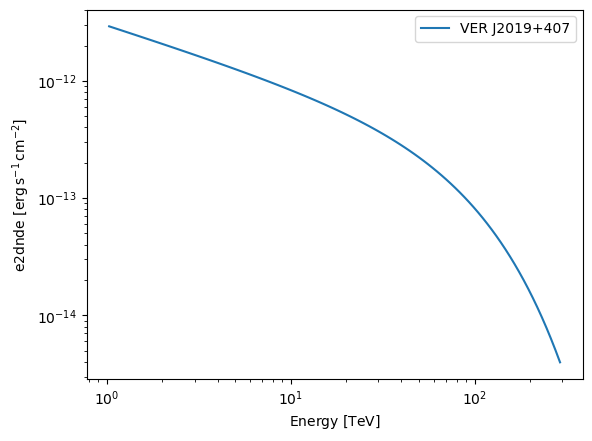

In [64]:
#plt.plot(energy, values*energy**2)
plt.loglog()


model = ExpCutoffPowerLawSpectralModel(
    amplitude=0.12e-12* u.Unit("cm-2 s-1 TeV-1"),
    index=2.5,
    lambda_=0.013 * u.Unit("TeV-1"),
    reference=3 * u.TeV,
)


energy_bounds = [1,300] * u.TeV
model.plot(energy_bounds,sed_type='e2dnde', label = "VER J2019+407")
#plt.ylim(1e-14,1e-11)
#plt.xlim(0.01,350)
plt.legend()
import os

# Cartella di destinazione
folder = "/Users/camillaquartiroli/Desktop/GAMMAPY/Notebook/Cygnus/plot_modelli"

# Crea la cartella se non esiste
os.makedirs(folder, exist_ok=True)

# Salvataggio del file
plt.savefig(os.path.join(folder, "VERJ2019+407.png"), dpi=300)
plt.show()

In [ ]:
ra = 305.03 * u.deg
dec = 40.57 * u.deg

c = SkyCoord(ra=ra, dec=dec, frame='icrs')

lon = c.galactic.l.deg * u.deg
lat = c.galactic.b.deg * u.deg

print(lon, lat)

In [56]:
gauss = GaussianSpatialModel(lon_0=78.33 * u.deg, lat_0=2.49 * u.deg, sigma="0.23 deg")
gammacygni = SkyModel(spatial_model=gauss,  spectral_model=model, name="VER J2019+407")
models = Models([gammacygni])

print(models.to_yaml())
models.write("VER J2019+407.yaml", overwrite=True)

components:
-   name: VER J2019+407
    type: SkyModel
    spectral:
        type: ExpCutoffPowerLawSpectralModel
        parameters:
        -   name: index
            value: 2.5
        -   name: amplitude
            value: 1.2e-13
            unit: TeV-1 s-1 cm-2
        -   name: reference
            value: 3.0
            unit: TeV
        -   name: lambda_
            value: 0.013
            unit: TeV-1
        -   name: alpha
            value: 1.0
    spatial:
        type: GaussianSpatialModel
        frame: icrs
        parameters:
        -   name: lon_0
            value: 78.33
            unit: deg
        -   name: lat_0
            value: 2.49
            unit: deg
        -   name: sigma
            value: 0.23
            unit: deg
        -   name: e
            value: 0.0
        -   name: phi
            value: 0.0
            unit: deg
metadata:
    creator: Gammapy 2.0
    date: '2026-02-14T02:34:44.705741'
    origin: null



<>:224: SyntaxWarning: invalid escape sequence '\,'
<>:224: SyntaxWarning: invalid escape sequence '\,'
/var/folders/x2/82wsvkbx2dndb9l7hp5f202h0000gn/T/ipykernel_64789/1330824880.py:224: SyntaxWarning: invalid escape sequence '\,'
  plt.ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E\;[\mathrm{erg\,cm^{-2}\,s^{-1}}]$")


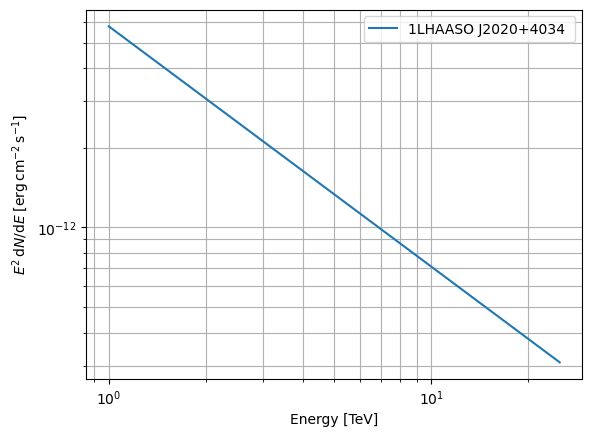

'\nenergy = np.array([9.999999999999996e-06,\n1.2214027581601694e-05,\n1.4918246976412701e-05,\n1.8221188003905077e-05,\n2.2255409284924663e-05,\n2.718281828459044e-05,\n3.320116922736547e-05,\n4.055199966844674e-05,\n4.953032424395113e-05,\n6.0496474644129425e-05,\n7.389056098930647e-05,\n9.025013499434118e-05,\n0.00011023176380641602,\n0.0001346373803500169,\n0.00016444646771097046,\n0.00020085536923187668,\n0.0002453253019710935,\n0.0002996410004739701,\n0.0003659823444367799,\n0.00044701184493300825,\n0.0005459815003314425,\n0.0006668633104092514,\n0.0008145086866496812,\n0.0009948431564193382,\n0.001215104175187349,\n0.0014841315910257664,\n0.0018127224187515123,\n0.0022140641620418716,\n0.002704264074261527,\n0.0033029955990964877,\n0.0040342879349273535,\n0.0049274904109325645,\n0.006018450378720822,\n0.0073509518924197315,\n0.00897847291650418,\n0.01096633158428459,\n0.013394307643944175,\n0.016359844299959264,\n0.01998195895104117,\n0.024406019776244986,\n0.02980957987041727,\

In [65]:
energy_bounds = [1, 25] * u.TeV
model = PowerLawSpectralModel(
    index=2.91,
    amplitude="2.36e-13 TeV-1 cm-2 s-1",
    reference= 3* u.TeV,
)

energy= np.logspace(np.log10(1), np.log10(25), 200) * u.TeV


dnde = model(energy)
e2dnde = (energy**2 * dnde).to("TeV cm-2 s-1")

plt.loglog(energy, e2dnde, label="1LHAASO J2020+4034 ")
plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E\;[\mathrm{erg\,cm^{-2}\,s^{-1}}]$")
plt.grid(which="both")
plt.legend()
import os

# Cartella di destinazione
folder = "/Users/camillaquartiroli/Desktop/GAMMAPY/Notebook/Cygnus/plot_modelli"

# Crea la cartella se non esiste
os.makedirs(folder, exist_ok=True)

# Salvataggio del file
plt.savefig(os.path.join(folder, "LHAASOJ2020+4034.png"), dpi=300)
plt.show()
"""
energy = np.array([9.999999999999996e-06,
1.2214027581601694e-05,
1.4918246976412701e-05,
1.8221188003905077e-05,
2.2255409284924663e-05,
2.718281828459044e-05,
3.320116922736547e-05,
4.055199966844674e-05,
4.953032424395113e-05,
6.0496474644129425e-05,
7.389056098930647e-05,
9.025013499434118e-05,
0.00011023176380641602,
0.0001346373803500169,
0.00016444646771097046,
0.00020085536923187668,
0.0002453253019710935,
0.0002996410004739701,
0.0003659823444367799,
0.00044701184493300825,
0.0005459815003314425,
0.0006668633104092514,
0.0008145086866496812,
0.0009948431564193382,
0.001215104175187349,
0.0014841315910257664,
0.0018127224187515123,
0.0022140641620418716,
0.002704264074261527,
0.0033029955990964877,
0.0040342879349273535,
0.0049274904109325645,
0.006018450378720822,
0.0073509518924197315,
0.00897847291650418,
0.01096633158428459,
0.013394307643944175,
0.016359844299959264,
0.01998195895104117,
0.024406019776244986,
0.02980957987041727,
0.03640950307332354,
0.04447066747699856,
0.05431659591362981,
0.06634244006277887,
0.0810308392757538,
0.09897129058743913,
0.12088380730216983,
0.14764781565577287,
0.18033744927828532,
0.22026465794806746,
0.26903186074297575,
0.3285962567444334,
0.4013483743087583,
0.49020801136381775,
0.598741417151979,
0.7313044183341555,
0.8932172336080563,
1.090977992765077,
1.3325235294553108,
1.6275479141900384,
1.9878915114295448,
2.428016174983235,
2.965585652982027,
3.62217449611248,
4.424133920089203,
5.403649372466923,
6.600032247661566,
8.061297591239896,
9.846091112290352,
12.026042841647763,
14.68864189654096,
17.940747726062142,
21.91287875606812,
26.764450551890974,
32.69017372472115,
39.92786835210949,
48.76800853272266,
59.56538013184622,
72.75331958389589,
88.86110520507884,
108.53519899064425,
132.5651914046359,
161.91549041765302,
197.76402658497815,
241.5495275357533,
295.0292591644553,
360.34955088141703,
440.13193534834164,
537.5783597888376,
656.599691373306,
801.9726740504731,
979.531636054334
]
) * u.TeV
values = np.array([
7.2007303677082924e-06,
9.10220292226037e-06,
1.2388811420364909e-05,
1.611135778090185e-05,
1.972347051992322e-05,
2.3319508883023988e-05,
2.6630301390398266e-05,
2.94090408940921e-05,
3.4317659787597445e-05,
3.537969269101633e-05,
3.514580025433865e-05,
3.425443829747931e-05,
3.172930001838038e-05,
2.719770273325324e-05,
2.39340981680553e-05,
2.0370949665156145e-05,
1.6563816112026686e-05,
1.3102683096636e-05,
9.956322825651166e-06,
7.467221238402805e-06,
5.5004613402597164e-06,
3.988916963282371e-06,
2.8726029430750196e-06,
2.0479419109836154e-06,
1.4131748331855357e-06,
9.8994205379467e-07,
6.805089111814547e-07,
4.6930581270730593e-07,
3.244514106566026e-07,
2.2366494871916036e-07,
1.5630753717627056e-07,
1.110031341465893e-07,
7.761093800792188e-08,
5.446752164659442e-08,
3.831920491332093e-08,
2.688187609898988e-08,
1.8715615203812466e-08,
1.308937931616537e-08,
9.04507856338961e-09,
6.235697364058753e-09,
4.259982303610402e-09,
2.898539479408413e-09,
1.96968423009304e-09,
1.333480803985218e-09,
9.001338202787882e-10,
6.052406670735755e-10,
4.050508461102763e-10,
2.6932535293162276e-10,
1.77630099231449e-10,
1.1601721972141334e-10,
7.491569942762989e-11,
4.775968366239241e-11,
3.0034032449649086e-11,
1.8635907798915795e-11,
1.1430382780724773e-11,
6.953415085187231e-12,
4.209858191331604e-12,
2.5407701739611153e-12,
1.529145648577804e-12,
9.181458585668726e-13,
5.502459272951832e-13,
3.292785635374159e-13,
1.968223491142692e-13,
1.175408553251409e-13,
7.01387939194056e-14,
4.1820011400277897e-14,
2.4912324221001966e-14,
1.4823118142335076e-14,
8.806174511308496e-15,
5.220502258724209e-15,
3.0859239676689495e-15,
1.8170914212795496e-15,
1.064479501072981e-15,
6.19398699542134e-16,
3.572709782379894e-16,
2.037577110407131e-16,
1.1453105823176534e-16,
6.319043583979424e-17,
3.404236100434198e-17,
1.7785101541419254e-17,
8.929018107803837e-18,
4.254458419392396e-18,
1.8901267472699343e-18,
7.626202863505992e-19,
2.6802383152091546e-19,
7.633234664481958e-20,
1.527255572588545e-20,
1.5087821157694164e-21,
1.756192057695257e-23,
0.0,
0.0,
0.0,
0.0
]) * u.Unit("TeV-1 s-1 cm-2")
template = TemplateSpectralModel(energy=energy, values=values)
template.plot(energy_bounds, sed_type="e2dnde", label = "VER J2019")
plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E\;[\mathrm{erg\,cm^{-2}\,s^{-1}}]$")
plt.grid(which="both")
plt.legend()
#plt.ylim(1e-14, 1e-12)
#plt.xlim(1, 10**4)
plt.legend()
plt.show()
"""

In [7]:
ra = 305.03 * u.deg
dec = 40.57 * u.deg

c = SkyCoord(ra=ra, dec=dec, frame='icrs')

lon = c.galactic.l.deg * u.deg
lat = c.galactic.b.deg * u.deg

print(lon, lat)

78.17868537346378 deg 2.375342182001096 deg


In [8]:
gauss = GaussianSpatialModel(lon_0=lon, lat_0=lat, sigma="0.38 deg")
gammacygni = SkyModel(spatial_model=gauss,  spectral_model=model, name="1LHAASO J2020+4034")
models = Models([gammacygni])

print(models.to_yaml())
models.write("1LHAASO J2020+4034.yaml", overwrite=True)

components:
-   name: 1LHAASO J2020+4034
    type: SkyModel
    spectral:
        type: PowerLawSpectralModel
        parameters:
        -   name: index
            value: 2.91
        -   name: amplitude
            value: 2.36e-13
            unit: TeV-1 s-1 cm-2
        -   name: reference
            value: 3.0
            unit: TeV
    spatial:
        type: GaussianSpatialModel
        frame: icrs
        parameters:
        -   name: lon_0
            value: 78.17868537346378
            unit: deg
        -   name: lat_0
            value: 2.375342182001096
            unit: deg
        -   name: sigma
            value: 0.38
            unit: deg
        -   name: e
            value: 0.0
        -   name: phi
            value: 0.0
            unit: deg
metadata:
    creator: Gammapy 2.0
    date: '2026-02-11T11:31:27.098238'
    origin: null



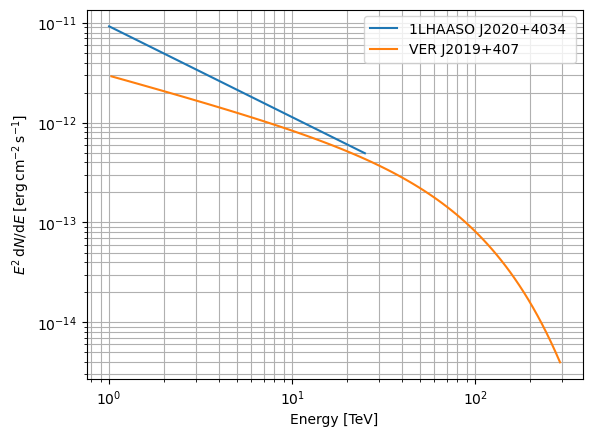

In [68]:
energy_bounds = [1, 25] * u.TeV
model = PowerLawSpectralModel(
    index=2.91,
    amplitude="2.36e-13 TeV-1 cm-2 s-1",
    reference= 3* u.TeV,
)

energy= np.logspace(np.log10(1), np.log10(25), 200) * u.TeV


dnde = model(energy)
e2dnde = (energy**2 * dnde).to("erg cm-2 s-1")

plt.loglog(energy, e2dnde, label="1LHAASO J2020+4034 ")
model = ExpCutoffPowerLawSpectralModel(
    amplitude=0.12e-12* u.Unit("cm-2 s-1 TeV-1"),
    index=2.5,
    lambda_=0.013 * u.Unit("TeV-1"),
    reference=3 * u.TeV,
)


energy_bounds = [1,300] * u.TeV
model.plot(energy_bounds,sed_type='e2dnde', label = "VER J2019+407")
plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E\;[\mathrm{erg\,cm^{-2}\,s^{-1}}]$")
plt.grid(which="both")
plt.legend()
import os

# Cartella di destinazione
folder = "/Users/camillaquartiroli/Desktop/GAMMAPY/Notebook/Cygnus/plot_modelli"

# Crea la cartella se non esiste
os.makedirs(folder, exist_ok=True)

# Salvataggio del file
plt.savefig(os.path.join(folder, "gammacygni.png"), dpi=300)
plt.show()